# RNAseq data cleanup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from pathlib import Path
mmc2_path = Path('data') / 'mmc2.csv'
rna_seq_data = pd.read_csv(mmc2_path)
rna_seq_data.head()

## an explorativ overview of the data

In [ ]:
print(rna_seq_data.describe())
print(rna_seq_data.isnull().sum())
print(rna_seq_data.nunique())

In [ ]:
rna_seq_data.info()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

### Creating a histogram of one cell type as an example

In [ ]:
sns.histplot(rna_seq_data["Tgd.g2+d17.LN"], bins=30, kde=True)

Because the histogram does not show any usefull information in the normal scale, I will perform a log-transformation of all RNAseq values and create a new data frame with them

In [ ]:
numeric_cols = rna_seq_data.select_dtypes(include=[np.number]).columns
print(numeric_cols)

In [ ]:
log_rna_seq = rna_seq_data.copy()
log_rna_seq[numeric_cols] = np.log1p(log_rna_seq[numeric_cols])
log_rna_seq.head()

In [ ]:
sns.histplot(log_rna_seq["Tgd.g2+d17.LN"], bins=30, kde=True)

After the log transformation there is more usefull information visible in the histogram

In [ ]:
for  x in numeric_cols:
    sns.histplot(log_rna_seq[x], bins=30, kde=True)

### Creating new data frames with only those cell types relevant to us

In [ ]:
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

In [ ]:
Tgd_rna = rna_seq_data[Tgd_cells].copy()
Tgd_rna.head()
log_Tgd_rna = log_rna_seq[Tgd_cells].copy()
log_Tgd_rna.head()

## Filtering out low expression / noise

Low values <1.5 are not due to a detectable expression level, but are rather caused by noise. Thereby they can be disregarded.

In [ ]:
noise_frac = (rna_seq_data[numeric_cols] < 1.5).sum() / rna_seq_data.shape[0]
print(noise_frac)

In [ ]:
print(noise_frac.mean())

In [ ]:
noise_frac_df = noise_frac.reset_index()
noise_frac_df.columns = ['cell_type', 'noise_fraction']

plt.figure(figsize=(15, 10))
sns.pointplot(data=noise_frac_df, x='cell_type', y='noise_fraction')
plt.xticks(rotation=90)
plt.ylabel('Fraction of values < 1.5')
plt.xlabel('Cell type')
plt.title('Noise fraction per cell type')

27.9% of all values are under the threshold of 1.5 and 31.1% under 2. The fraction of low expressed Genes is similar over all cell types

In [ ]:
total_expression = rna_seq_data.iloc[:, 1:].sum(axis=1)
print(total_expression)

In [ ]:
(((rna_seq_data.iloc[:, 1:] < 1.5).sum(axis=1) / 86) < 0.1).sum()


### filtering out genes which are only expressed in less than 25 % of cell types (10 % for comparison)

In [ ]:
gene_expr_frac = (rna_seq_data.iloc[:, 1:] > 1.5).sum(axis=1) / (rna_seq_data.shape[1] - 1)
rna_seq_filtered = rna_seq_data[rna_seq_data.index.isin(gene_expr_frac[gene_expr_frac >= 0.25].index)].copy()
rna_seq_filtered.info()

In [ ]:
rna_seq_rare_genes = rna_seq_data[rna_seq_data.index.isin(gene_expr_frac[gene_expr_frac < 0.25].index)].copy()
rna_seq_rare_genes.info()

## Creating a function for log-tranformation

In [ ]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

### Using the log_transform function on the filtered values and creating a histogram

In [ ]:
log_rna_filtered = log_transform(rna_seq_filtered)
log_rna_filtered.head()

In [ ]:
sns.histplot(log_rna_filtered["Tgd.g2+d17.LN"], bins=30, kde=True)

## Combination of filtering rarely expressed genes and genes with a low max expression

In [ ]:
gene_max = rna_seq_data.iloc[:, 1:].max(axis=1)
print(gene_max)
mask = (gene_expr_frac >= 0.25) & (gene_max >= 10)
rna_filtered_2 = rna_seq_data[mask].copy()
rna_filtered_2.info()

Ceck if any rarely expressed genes have high expression in one cell type

In [ ]:
rna_seq_rare_genes[gene_max >= 10].info()

In [ ]:
log_rna_filtered_2 = log_transform(rna_filtered_2)
sns.histplot(log_rna_filtered_2["Tgd.g2+d17.LN"], bins=30, kde=True)

## Only an absolute filter

In [ ]:
rna_filtered_absolute = rna_seq_data[rna_seq_data.iloc[:, 1:].max(axis=1) >= 10].copy()
rna_filtered_absolute.info()
log_rna_filtered_absolute = log_transform(rna_filtered_absolute)
sns.histplot(log_rna_filtered_absolute["Tgd.g2+d17.LN"], bins=30, kde=True)

## Filtering by Variation

### Variation filtering using the already filtered data

In [ ]:
gene_var_coef_filtered = rna_filtered_2.iloc[:, 1:].std(axis=1) / rna_filtered_2.iloc[:, 1:].mean(axis=1)
sns.histplot(gene_var_coef_filtered, bins=30, kde=True)

In [ ]:
var_coef_threshold_filtered = gene_var_coef_filtered.quantile(0.10)
rna_variable_genes_filtered = rna_filtered_2[gene_var_coef_filtered >= var_coef_threshold_filtered].copy()
rna_variable_genes_filtered.info()

In [ ]:
top1000_threshold_filtered = gene_var_coef_filtered.nlargest(1000).index
rna_var_top1000_filtered = rna_filtered_2.loc[top1000_threshold_filtered].copy()
rna_var_top1000_filtered.describe()

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_filtered_2.iloc[:, 1:].mean(axis=1)), gene_var_coef_filtered, s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_variable_genes_filtered.iloc[:, 1:].mean(axis=1)), rna_variable_genes_filtered.iloc[:, 1:].std(axis=1) / rna_variable_genes_filtered.iloc[:, 1:].mean(axis=1), s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('variable genes: scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_var_top1000_filtered.iloc[:, 1:].mean(axis=1)), rna_var_top1000_filtered.iloc[:, 1:].std(axis=1) / rna_var_top1000_filtered.iloc[:, 1:].mean(axis=1), s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('top 1000 variable genes: scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

### Creating the same scatter plot, but with the unfiltered data

In [ ]:
gene_var_coef = rna_seq_data.iloc[:, 1:].std(axis=1) / rna_seq_data.iloc[:, 1:].mean(axis=1)
sns.histplot(gene_var_coef, bins=30, kde=True)

In [ ]:
var_coef_threshold = gene_var_coef.quantile(0.40)
rna_variable_genes = rna_seq_data[gene_var_coef >= var_coef_threshold].copy()

In [ ]:
top1000_threshold = gene_var_coef.nlargest(1000).index
rna_var_top1000 = rna_seq_data.loc[top1000_threshold].copy()

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_seq_data.iloc[:, 1:].mean(axis=1)), gene_var_coef, s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_variable_genes.iloc[:, 1:].mean(axis=1)), rna_variable_genes.iloc[:, 1:].std(axis=1) / rna_variable_genes.iloc[:, 1:].mean(axis=1), s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('variable genes: scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(rna_var_top1000.iloc[:, 1:].mean(axis=1)), rna_var_top1000.iloc[:, 1:].std(axis=1) / rna_var_top1000.iloc[:, 1:].mean(axis=1), s=5, alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('top 1000 variable genes: scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

# Coloring the scatter plot to visualize gene functions

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import gseapy as gp
from pathlib import Path
mmc2_path = Path('data') / 'mmc2.csv'
rna_seq_data = pd.read_csv(mmc2_path)
gene_var_coef = rna_seq_data.iloc[:, 1:].std(axis=1) / rna_seq_data.iloc[:, 1:].mean(axis=1)

In [ ]:
go_genesets = gp.get_library(name='GO_Biological_Process_2023', organism='Mouse')

instead of every gene in one category, it is better to have every category for each gene

In [ ]:
gene2terms = {}
for term, genes in go_genesets.items():
    for gene in genes:
        gene2terms.setdefault(gene, set()).add(term)


the categories are put into broader categories ("ribosom" can match "ribosome" and "ribosomal")

In [ ]:
category_keywords = {
    "housekeeping":  ["ribosom", "translation", "RNA processing",
                      "proteasome", "DNA repair", "cell cycle"],
    "immune":        ["immune", "T cell", "lymphocyte", "cytokine",
                      "interferon", "NF-kB", "antigen"],
    "metabolism":    ["metabolic", "biosynthesis", "oxidation",
                      "glycolysis", "lipid", "mitochondri"],
    "transcription": ["transcription", "chromatin", "histone", "epigenetic"],
    "signaling":     ["signaling", "kinase", "receptor", "MAPK", "PI3K"],
}

these steps are performed in the next cell:
- get GO terms
- loop over all GO terms of this gene
- check each keyword

In [ ]:
def assign_category(gene):
    terms = gene2terms.get(gene.upper(), set())   
    for category, keywords in category_keywords.items():
        for t in terms:                   
            for kw in keywords:           
                if kw.lower() in t.lower():
                    return category       
    return "other"                        

creating a data frame with the columns: gene name, log2 mean expresssion, variance coef

In [ ]:
mean_expression = rna_seq_data.iloc[:, 1:].mean(axis=1)
meanlog2_expression = np.log2(rna_seq_data.iloc[:, 1:].mean(axis=1))
meanexp_varcoef = pd.DataFrame({"gene": rna_seq_data["Unnamed: 0"], "mean_expression": mean_expression, "gene_var_coef": gene_var_coef})
meanlog2exp_varcoef = pd.DataFrame({"gene": rna_seq_data["Unnamed: 0"], "mean_log2_expression": meanlog2_expression, "gene_var_coef": gene_var_coef})
meanlog2exp_varcoef.head()

In [ ]:
meanexp_varcoef["category"] = meanexp_varcoef["gene"].apply(assign_category)
meanexp_varcoef.head()
meanlog2exp_varcoef["category"] = meanlog2exp_varcoef["gene"].apply(assign_category)

In [ ]:
color_map = {
    "housekeeping":  "#2196F370",  
    "immune":        "#F4433670",  
    "metabolism":    "#4CAF5070",  
    "transcription": "#FF980070",  
    "signaling":     "#9C27B070",  
    "other":         "#CCCCCC70",  
}

color_map_housekeeping = {  
    "housekeeping":  "#2196F3",  
    "immune":        "#F4433600",  
    "metabolism":    "#4CAF4F00",  
    "transcription": "#FF990000",  
    "signaling":     "#9B27B000",
    "other":         "#CCCCCC70",  
}

color_map_immune = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#F44336",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_metabolism = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#4CAF50",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_transcription = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#FF9800",  
    "signaling":     "#CCCCCC00",  
    "other":         "#CCCCCC70",  
}

color_map_signaling = {
    "housekeeping":  "#CCCCCC00",  
    "immune":        "#CCCCCC00",  
    "metabolism":    "#CCCCCC00",  
    "transcription": "#CCCCCC00",  
    "signaling":     "#9C27B0",  
    "other":         "#CCCCCC70",  
}

fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    group = meanlog2exp_varcoef[meanlog2exp_varcoef["category"] == category]
    ax.scatter(
        group["mean_log2_expression"],
        group["gene_var_coef"],
        c=color_map_housekeeping[category],
        label=f"{category} (n={len(group)})",  
        s=5          
    )

ax.set_xlabel("log2(Mean Expression)")
ax.set_ylabel("Variance Coefficient")
ax.legend(markerscale=4, loc="upper right")
ax.set_title("Gene Categories by GO Annotation")
plt.tight_layout()
plt.show()

plotting without log transformation, but with log scale x-axis

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    group = meanexp_varcoef[meanexp_varcoef["category"] == category]
    ax.scatter(
        group["mean_expression"],
        group["gene_var_coef"],
        c=color_map_housekeeping[category],
        label=f"{category} (n={len(group)})",  
        s=5          
    )

ax.set_xlabel("Mean Expression")
ax.set_ylabel("Variance Coefficient")
ax.set_xscale("log")
ax.legend(markerscale=4, loc="upper right")
ax.set_title("Gene Categories by GO Annotation")
plt.tight_layout()
plt.show()

plotting with a cutoff at 5000 and 1000

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    group = meanexp_varcoef[meanexp_varcoef["category"] == category]
    ax.scatter(
        group["mean_expression"],
        group["gene_var_coef"],
        c=color_map_housekeeping[category],
        label=f"{category} (n={len(group)})",  
        s=5          
    )

ax.set_xlabel("Mean Expression")
ax.set_ylabel("Variance Coefficient")
ax.set_xlim(1, 5000)
ax.legend(markerscale=4, loc="upper right")
ax.set_title("Gene Categories by GO Annotation")
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

for category in ["other"] + [k for k in color_map if k != "other"]:
    group = meanexp_varcoef[meanexp_varcoef["category"] == category]
    ax.scatter(
        group["mean_expression"],
        group["gene_var_coef"],
        c=color_map[category],
        label=f"{category} (n={len(group)})",  
        s=5          
    )

ax.set_xlabel("Mean Expression")
ax.set_ylabel("Variance Coefficient")
ax.set_xlim(1, 1000)
ax.legend(markerscale=4, loc="upper right")
ax.set_title("Gene Categories by GO Annotation")
plt.savefig("tilmann_plots/gene_variance_over_mean_scatter(limit1000).png", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

# Is there a relationship between accessibility signal and distance to the TSS?

## opening ATAC data and filtering with the p value (jupyter_lotta)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
from pathlib import Path
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)
ATAC_pfiltered = ATAC_data[ATAC_data['_-log10_bestPvalue'] > -np.log10(0.05)]
ATAC_pfiltered

### creating a file for the filtered ATACseq data

In [ ]:
ATAC_pfiltered.to_csv('data/ATAC_pfiltered.csv', index=False, header=True)
ATAC_pfiltered_check = pd.read_csv('data/ATAC_pfiltered.csv')
ATAC_pfiltered_check

## plot accessibility signal over distance to TSS

### open "Gene annotations"

In [ ]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]

gene_annotations_path = Path('data') / 'Gene annotations.txt'
gene_annotations = pd.read_csv(gene_annotations_path, sep="\t", names=cols)
gene_annotations.to_csv('data/gene_annotations.csv', index=False)
gene_annotations_check = pd.read_csv('data/gene_annotations.csv')
gene_annotations_check

### Match ATAC genes to gene annotations and compute distance to TSS

In [ ]:
gene_and_TSS = gene_annotations[["gene_name", "txStart"]].copy()


ATAC_merged = ATAC_pfiltered.merge(
    gene_and_TSS,
    left_on="genes.within.100Kb",
    right_on="gene_name",
    how="right"
)


ATAC_merged["distance_to_tss"] = abs(ATAC_merged["Summit"] - ATAC_merged["txStart"])


keep_cols = list(ATAC_pfiltered.columns[8:]) + ["distance_to_tss"]
ATAC_dis_TSS = ATAC_merged[keep_cols].copy()

ATAC_dis_TSS

### creating a scatter plot connecting accessibility score to distance from TSS

In [ ]:
plot_data = ATAC_dis_TSS.iloc[:, :-1]
x = ATAC_dis_TSS['distance_to_tss']

plt.figure(figsize=(15, 10))
for col in plot_data.columns:
    plt.scatter(x, plot_data[col], alpha=0.25, s=8)
plt.xlabel('Distance to TSS')
plt.ylabel('ATAC value')
plt.title('ATAC values vs. distance to TSS (all ATAC columns)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='TSS')
plt.axvline(ATAC_dis_TSS['distance_to_tss'].median(), color='red', linestyle='--', linewidth=1, label='Median distance to TSS')
plt.legend()
plt.show()


There seems to be a problem with this plot. Distance to TSS should not be greater than 100.000.
Since the median and the mean are very low compared to the highest values one possible solution coul be to just remove very high values.

In [ ]:
ATAC_dis_TSS['distance_to_tss'].quantile(0.99)

Remove the top 1 % of values

In [ ]:
ATAC_dis_TSS_filtered = ATAC_dis_TSS.drop(ATAC_dis_TSS[ATAC_dis_TSS['distance_to_tss'] > ATAC_dis_TSS['distance_to_tss'].quantile(0.99)].index)
ATAC_dis_TSS_filtered

In [ ]:
plot_data_filtered = ATAC_dis_TSS_filtered.iloc[:, :-1]
x = ATAC_dis_TSS_filtered['distance_to_tss']

plt.figure(figsize=(15, 10))
for col in plot_data_filtered.columns:
    plt.scatter(x, plot_data_filtered[col], alpha=0.25, s=8, color='steelblue')
plt.xlabel('Distance to TSS')
plt.ylabel('ATAC value')
plt.title('ATAC values vs. distance to TSS (all ATAC columns)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='TSS')
plt.axvline(ATAC_dis_TSS_filtered['distance_to_tss'].median(), color='red', linestyle='--', linewidth=1, label='Median distance to TSS')
plt.legend()
plt.show()

for a max distance of 100.000

In [ ]:
ATAC_dis_TSS_100kb = ATAC_dis_TSS.drop(ATAC_dis_TSS[ATAC_dis_TSS['distance_to_tss'] > 100000].index)

plot_data_100kb = ATAC_dis_TSS_100kb.iloc[:, :-1]
x = ATAC_dis_TSS_100kb['distance_to_tss']

plt.figure(figsize=(15, 10))
for col in plot_data_100kb.columns:
    plt.scatter(x, plot_data_100kb[col], alpha=0.25, s=8, color='steelblue')
plt.xlabel('Distance to TSS')
plt.ylabel('ATAC value')
plt.title('ATAC values vs. distance to TSS (all ATAC columns)')
plt.axvline(0, color='red', linestyle='--', linewidth=1, label='TSS')
plt.axvline(ATAC_dis_TSS_100kb['distance_to_tss'].median(), color='red', linestyle='--', linewidth=1, label='Median distance to TSS')
plt.legend()
plt.show()

## creating a histogram of active OCRs in relation to distance from TSS

In [ ]:
ATAC_dis_TSS_filtered.describe()

In [ ]:
ATAC_value_median = ATAC_dis_TSS_filtered.iloc[:, :-1].median(axis=None)

In [ ]:
atac_values = ATAC_dis_TSS_filtered.iloc[:, :-1]

active_atac_counts = (atac_values.fillna(0) > ATAC_value_median).sum(axis=1)

distances = ATAC_dis_TSS_filtered['distance_to_tss']

plt.figure(figsize=(10, 7))
plt.hist(distances, bins=50, weights=active_atac_counts)
plt.xlabel('Distance to TSS')
plt.ylabel('Number of above-median ATAC values per row')
plt.title('histogram: ATAC count vs distance to TSS')
plt.show()

the drop of at 100kb could be due to the fact that there should not be any values above 100kb in the first place

creating the same histogram with only those distances of up to 100kb

In [ ]:
atac_values = ATAC_dis_TSS_100kb.iloc[:, :-1]

active_atac_counts = (atac_values.fillna(0) > ATAC_value_median).sum(axis=1)

distances = ATAC_dis_TSS_100kb['distance_to_tss']

plt.figure(figsize=(10, 7))
plt.hist(distances, bins=20, weights=active_atac_counts)
plt.xlabel('Distance to TSS')
plt.ylabel('Number of above-median ATAC values per row')
plt.title('histogram: ATAC count vs distance to TSS up to 100kb')
plt.savefig('tilmann_plots/histogram_ATAC_count_vs_distance_to_TSS_100kb.png', dpi=300, bbox_inches="tight")
plt.show()

### quantifying the relationship between accessibility score and distance to TSS

In [ ]:
counts, bin_edges, patches = plt.hist(distances, bins=20, weights=active_atac_counts)
print(counts[0])
print(counts[1:])
print(counts[1:].mean())
print(counts[1:].std())

In [ ]:
from scipy import stats

first_bin_count = counts[0]
other_bin_counts = counts[1:]

ttest_result = stats.ttest_1samp(other_bin_counts, popmean=first_bin_count)

print('First bin count:', first_bin_count)
print('Other bins counts:', other_bin_counts)
print('Other bins mean:', other_bin_counts.mean())
print('One-sample t-test result:', ttest_result)
print('p-value:', ttest_result.pvalue)


In [ ]:
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
other_bin_centers = bin_centers[1:]
other_bin_counts = counts[1:]

linreg = stats.linregress(other_bin_centers, other_bin_counts)

print('Linear regression (excluding first bin):')
print('Slope:', linreg.slope)
print('R-squared:', linreg.rvalue ** 2)
print('p-value:', linreg.pvalue)

plt.figure(figsize=(10, 7))
plt.scatter(other_bin_centers, other_bin_counts, label='Bin counts', color='steelblue')
plt.plot(other_bin_centers, linreg.intercept + linreg.slope * other_bin_centers, color='red', label='Linear fit')
plt.xlabel('Distance bin center (bp)')
plt.ylabel('Count of above-median ATAC values')
plt.title('Linear regression on counts for bins 2-20')
plt.savefig('tilmann_plots/linear_regression_ATAC_count_vs_distance_to_TSS_100kb_no_Promotors.png', dpi=300, bbox_inches="tight")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
predicted_counts = linreg.intercept + linreg.slope * other_bin_centers
residuals = other_bin_counts - predicted_counts
print('Residuals mean:', np.mean(residuals))
print('Residuals std:', np.std(residuals, ddof=1))
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(residuals, bins=15, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of residuals')
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('QQ plot of residuals')
plt.tight_layout()
plt.show()


## Looking at the OCRs with very high distances to the TSS

In [ ]:

gene_and_TSS = gene_annotations[["gene_name", "txStart"]].copy()


ATAC_merged = ATAC_pfiltered.merge(
    gene_and_TSS,
    left_on="genes.within.100Kb",
    right_on="gene_name",
    how="right"
)


ATAC_merged["distance_to_tss"] = abs(ATAC_merged["Summit"] - ATAC_merged["txStart"])

In [ ]:
ATAC_dis_TSS_highest_with_na = ATAC_merged.drop(ATAC_merged[ATAC_merged['distance_to_tss'] < ATAC_merged['distance_to_tss'].quantile(0.999)].index)
ATAC_dis_TSS_highest = ATAC_dis_TSS_highest_with_na.dropna(subset=["distance_to_tss"]).copy()
ATAC_dis_TSS_highest

In [ ]:
plt.figure(figsize=(10, 7))
plt.hist(ATAC_dis_TSS_highest["distance_to_tss"], bins=200,)
plt.xlabel('Distance to TSS')
plt.ylabel('Number of ATAC Peaks with that distance')
plt.title('histogram: distribution of high distances to tss')
plt.show()

In [ ]:
ATAC_dis_TSS_highest_filtered = ATAC_dis_TSS_highest.drop(
    ATAC_dis_TSS_highest[
        ATAC_dis_TSS_highest[ATAC_dis_TSS_highest.columns[8:97]].max(axis=1) < 40
    ].index)
ATAC_dis_TSS_highest_filtered

most OCRs with high accessibility scores and large distances from the TSS seem to be conetcted to similar genes:

- "Mir" genes are coding for microRNA which has regulatory functions
- I could not find any "Bc1" genes on the X-chromosome
- some of the OCRs lie inside of other genes, therefore it is not likely that they are functionally connected to the gene from the data frame

# Clustering of cell types based on ATACseq data

## creating ATAC data frame with only our cell types

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')

Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]

ATAC_seq_gd_anot = pd.concat([ATAC_seq[[
        "ImmGenATAC1219.peakID",
        "chrom",
        "Summit",
        "mm10.60way.phastCons_scores",
        "_-log10_bestPvalue",
        "Included.in.systematic.analysis",
        "TSS", 
        "genes.within.100Kb"
    ]],
    ATAC_seq[Tgd_cells[1:]].copy()], axis=1)

ATAC_seq_gd_anot.to_csv('data/ATAC_seq_gd_anot.csv', index=False, header=True)
ATAC_seq_gd_check = pd.read_csv('data/ATAC_seq_gd_anot.csv')
ATAC_seq_gd_check

## creating lists of each cell group

In [ ]:
print("Tgd_cell_lineage:", Tgd_cells[1:])

gdT = ["Tgd.g2+d17.24a+.Th",
    "Tgd.g2+d17.LN",
    "Tgd.g2+d1.24a+.Th",
    "Tgd.g2+d1.LN",
    "Tgd.g1.1+d1.24a+.Th",
    "Tgd.g1.1+d1.LN",
    "Tgd.Sp"]
print("gdT:", gdT)

abT = ["preT.DN1.Th",
    "preT.DN2a.Th",
    "preT.DN2b.Th",
    "preT.DN3.Th",
    "T.DN4.Th",
    "T.ISP.Th",
    "T.DP.Th",
    "T.4.Th",
    "T.8.Th",
    "T.4.Nve.Sp",
    "T.4.Nve.Fem.Sp",
    "T.8.Nve.Sp",
    "Treg.4.FP3+.Nrplo.Co",
    "Treg.4.25hi.Sp",
    "NKT.Sp"]
print("abT:", abT)

Act_T = ["T.4.Sp.aCD3+CD40.18hr",
         "T8.TN.P14.Sp",
         "T8.IEL.LCMV.d7.SI",
         "T8.TE.LCMV.d7.Sp",
         "T8.MP.LCMV.d7.Sp",
         "T8.Tcm.LCMV.d180.Sp",
         "T8.Tem.LCMV.d180.Sp",
         "NKT.Sp.LPS.3hr",
         "NKT.Sp.LPS.18hr",
         "NKT.Sp.LPS.3d"]
print("Act_T:", Act_T)

B_cells = ["proB.CLP.BM",
           "proB.FrA.BM",
           "proB.FrBC.BM",
           "preB.FrD.BM",
           "B.FrE.BM",
           "B1b.PC",
           "B.T1.Sp",
           "B.T2.Sp",
           "B.T3.Sp",
           "B.Sp",
           "B.Fem.Sp",
           "B.MZ.Sp",
           "B.Fo.Sp",
           "B.mem.Sp",
           "B.GC.CB.Sp",
           "B.GC.CC.Sp",
           "B.PB.Sp",
           "B.PC.Sp",
           "B.PC.BM"]
print("B_cells:", B_cells)

Stem = ["LTHSC.34-.BM",
         "LTHSC.34+.BM",
         "STHSC.150-.BM",
         "MPP4.135+.BM",
         "MPP3.48+.BM"]
print("Stem:", Stem)

ILC_cells = ["NK.27+11b-.BM",
        "NK.27+11b+.BM",
        "NK.27-11b+.BM",
        "NK.27+11b-.Sp",
        "NK.27+11b+.Sp",
        "NK.27-11b+.Sp",
        "ILC2.SI",
        "ILC3.NKp46-CCR6-.SI",
        "ILC3.NKp46+.SI",
        "ILC3.CCR6+.SI"]
print("ILC:", ILC_cells)

MF_GN_cells = ["GN.BM",
                "GN.Sp",
                "GN.Thio.PC",
                "MF.pIC.Alv.Lu",
                "MF.226+II+480lo.PC",
                "MF.ICAM+480hi.PC",
                "MF.RP.Sp",
                "MF.LP.SI",
                "MF.Alv.Lu",
                "MF.microglia.CNS",
                "MF.PC",
                "MF.Fem.PC"]
print("MF/GN:", MF_GN_cells)

Mo = ["Mo.6C+II-.Bl",
       "Mo.6C-II-.Bl"]
print("Mo:", Mo)

DCs = ["DC.4+.Sp",
        "DC.8+.Sp",
        "DC.pDC.Sp",
        "DC.103+11b+.SI",
        "DC.103+11b-.SI"]
print("DCs:", DCs)

Stroma = ["FRC.SLN",
          "IAP.SLN",
          "BEC.SLN",
          "LEC.SLN",
          "Ep.MEChi.Th"]
print("Stroma:", Stroma)

cells_groups = pd.DataFrame({
    "gdT": pd.Series(gdT),
    "abT": pd.Series(abT),
    "Act_T": pd.Series(Act_T),
    "B_cells": pd.Series(B_cells),
    "Stem": pd.Series(Stem),
    "ILC": pd.Series(ILC_cells),
    "MF/GN": pd.Series(MF_GN_cells),
    "Mo": pd.Series(Mo),
    "DC": pd.Series(DCs),
    "Stroma": pd.Series(Stroma)
})
cells_groups.to_csv('data/cells_groups.csv', index=False, header=True)
cells_groups_check = pd.read_csv('data/cells_groups.csv')
cells_groups_check


## clustering using PCA

### doing PCA analyses

First I have to rearrange the data frame, so that rows = cell types

In [ ]:
ATAC_seq_PCA = ATAC_seq.iloc[:,8:].T.copy()
ATAC_seq_PCA.columns = ATAC_seq["ImmGenATAC1219.peakID"]
ATAC_seq_PCA_gd = ATAC_seq[Tgd_cells[1:]].T.copy()
ATAC_seq_PCA_gd.columns = ATAC_seq["ImmGenATAC1219.peakID"]

Now I perform PCA analysis with all cell types and also just with the Tgd lineage

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = ATAC_seq_PCA.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_ATAC = pd.DataFrame(pcs, index=ATAC_seq_PCA.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_ATAC_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())


In [ ]:
X = ATAC_seq_PCA_gd.select_dtypes(float).values


X_scaled_gd = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled_gd)


pca_ATAC_gd = pd.DataFrame(pcs, index=ATAC_seq_PCA_gd.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_ATAC_gd_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())


visualizing the PCA results

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cell_group_map = {
    cell: group
    for group in cells_groups.columns
    for cell in cells_groups[group].dropna()
}

pca_ATAC["cell_type"] = pca_ATAC.index.map(cell_group_map).fillna("other")

group_palette = {
    "gdT": "darkorchid",
    "abT": "tab:green",
    "Act_T": "tab:orange",
    "B_cells": "tab:blue",
    "Stem": "tab:red",
    "ILC": "darkslategrey",
    "MF/GN": "tab:brown",
    "Mo": "tab:pink",
    "DC": "tab:cyan",
    "Stroma": "tab:olive",
    "other": "lightgrey",
}

sns.scatterplot(
    data=pca_ATAC,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_ATAC_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_ATAC_exp_var[1]:.1%})")
plt.title("PCA of all cell types based on ATAC-seq data (PC1 vs PC2)")
plt.savefig("tilmann_plots/PCA of all cell types based on ATAC-seq data (PC1 vs PC2).png", dpi=300, bbox_inches="tight")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


- some cells types are grouped quite well using PCA analysis
    - especially B-cells are grouped well
    - T-cells (with ILC) are all grouped together, but there is no distance visible between the diffrenet kinds of T-cells
- the first two PCAs only explain 17,7% of variance
    - this is likely due to the large number of original dimensions

In [ ]:
sns.scatterplot(
    data=pca_ATAC,
    x="PC1",
    y="PC3",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_ATAC_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_ATAC_exp_var[2]:.1%})")
plt.title("PCA of all cell types based on ATAC-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [ ]:
pca_ATAC_gd["sample"] = pca_ATAC_gd.index

palette = dict(zip(
    pca_ATAC_gd["sample"],
    sns.color_palette("viridis", n_colors=len(pca_ATAC_gd))
))

sns.scatterplot(data=pca_ATAC_gd, x="PC1", y="PC2", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_ATAC_gd_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_ATAC_gd_exp_var[1]:.1%})")
plt.title("PCA of Tgd lineage based on ATAC-seq data (PC1 vs PC2)")
plt.savefig("tilmann_plots/PCA of Tgd lineage based on ATAC-seq data (PC1 vs PC2).png", dpi=300, bbox_inches="tight")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

It looks like there is clear differentiation route in these two artifical dimensions

In [ ]:
sns.scatterplot(data=pca_ATAC_gd, x="PC1", y="PC3", hue="sample", palette=palette, s=100, alpha=0.8)
plt.xlabel("PC1" + f" ({pca_ATAC_gd_exp_var[0]:.1%})")
plt.ylabel("PC3" + f" ({pca_ATAC_gd_exp_var[2]:.1%})")
plt.title("PCA of Tgd lineage based on ATAC-seq data (PC1 vs PC3)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### clustering using k-means and comparing with cell lineage

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

pca_features = [f"PC{i+1}" for i in range(min(10, pca_ATAC.shape[1]))]
X_pca = pca_ATAC[pca_features].values

silhouette_scores = []
k_values = range(2, 20)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on PCA-transformed ATAC data")
plt.grid(True, alpha=0.3)
plt.show()

kmeans_opt = KMeans(n_clusters=best_k, random_state=42, n_init=20)
pca_ATAC["kmeans_cluster"] = kmeans_opt.fit_predict(X_pca).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_ATAC,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab20",
    s=100,
    alpha=0.8
)
plt.title(f"KMeans clustering on PCA of ATAC data (k={best_k})")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.savefig("tilmann_plots/PCA_kmeans_clustering_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

print(pca_ATAC.groupby(["kmeans_cluster", "cell_type"]).size().unstack(fill_value=0))


### clustering only the T cells with PCA and k-means

In [ ]:
cells_groups = pd.read_csv('data/cells_groups.csv')
cells_groups_T = cells_groups.iloc[:, 0:3]
T_cells = cells_groups_T.melt(var_name="group", value_name="cell").dropna()
T_cells

In [ ]:

ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')

ATAC_seq_PCA_T = ATAC_seq[T_cells["cell"]].T.copy()
ATAC_seq_PCA_T.columns = ATAC_seq["ImmGenATAC1219.peakID"]

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


X = ATAC_seq_PCA_T.select_dtypes(float).values


X_scaled = StandardScaler().fit_transform(X)


pca = PCA(n_components=10)
pcs = pca.fit_transform(X_scaled)


pca_ATAC_T = pd.DataFrame(pcs, index=ATAC_seq_PCA_T.index,
                     columns=[f"PC{i+1}" for i in range(pcs.shape[1])])
print(pca.explained_variance_ratio_)
pca_ATAC_T_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cell_group_map = {
    cell: group
    for group in cells_groups.columns
    for cell in cells_groups[group].dropna()
}

pca_ATAC_T["cell_type"] = pca_ATAC_T.index.map(cell_group_map).fillna("other")

group_palette = {
    "gdT": "darkorchid",
    "abT": "tab:green",
    "Act_T": "tab:orange",
    "B_cells": "tab:blue",
    "Stem": "tab:red",
    "ILC": "darkslategrey",
    "MF/GN": "tab:brown",
    "Mo": "tab:pink",
    "DC": "tab:cyan",
    "Stroma": "tab:olive",
    "other": "lightgrey",
}

sns.scatterplot(
    data=pca_ATAC_T,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.xlabel("PC1" + f" ({pca_ATAC_T_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_ATAC_T_exp_var[1]:.1%})")
plt.title("PCA of T cells based on ATAC-seq data (PC1 vs PC2)")
plt.savefig("tilmann_plots/PCA of T cells based on ATAC-seq data (PC1 vs PC2).png", dpi=300, bbox_inches="tight")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

pca_features = [f"PC{i+1}" for i in range(min(10, pca_ATAC_T.shape[1]))]
X_pca = pca_ATAC_T[pca_features].values

kmeans_opt = KMeans(n_clusters=3, random_state=42, n_init=20)
pca_ATAC_T["kmeans_cluster"] = kmeans_opt.fit_predict(X_pca).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=pca_ATAC_T,
    x="PC1",
    y="PC2",
    hue="kmeans_cluster",
    palette="tab10",
    s=100,
    alpha=0.8
)
plt.title(f"KMeans clustering on PCA of ATAC data of T cells(k={best_k})")
plt.legend(title="cluster", bbox_to_anchor=(1, 1), loc="upper left")
plt.show()

print(pca_ATAC_T.groupby(["kmeans_cluster", "cell_type"]).size().unstack(fill_value=0))

T cells are difficult to distinguish based on their chromatin signature using k means

## trying U-map for visualization

In [ ]:
import umap

umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)

X_raw = ATAC_seq_PCA.select_dtypes(float).values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

X_umap = umap_reducer.fit_transform(X_raw_scaled)
umap_df = pd.DataFrame(
    X_umap,
    index=ATAC_seq_PCA.index,
    columns=['UMAP1', 'UMAP2']
)
umap_df['cell_type'] = pca_ATAC['cell_type']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='cell_type',
    palette=group_palette,
    s=100,
    alpha=0.8
)
plt.title('UMAP of all cell types based on raw ATAC-seq data')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

kmeans_umap = KMeans(n_clusters=best_k, random_state=42, n_init=20)
umap_df['umap_cluster'] = kmeans_umap.fit_predict(umap_df[['UMAP1', 'UMAP2']]).astype(str)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='umap_cluster',
    palette='tab20',
    s=100,
    alpha=0.8
)
plt.title(f'KMeans clusters on UMAP projection of raw ATAC data (k={best_k})')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


- some cell groups are more distinct than others
    - this can also be seen with the k-means clustering
- k-means clustering seems to give similar results as the Umap

## Heatmap with hierarchical clustering (replicating figure 2a from Yoshida et al., but only with our cells types)

### load a data frame with only our cell types

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')
Tgd_cells = ["Unnamed: 0" ,
            "MPP4.135+.BM" ,
            "preT.DN1.Th" ,
            "preT.DN2a.Th" ,
            "preT.DN2b.Th" ,
            "preT.DN3.Th" ,
            "T.DN4.Th" ,
            "Tgd.g1.1+d1.24a+.Th" ,
            "Tgd.g2+d1.24a+.Th" ,
            "Tgd.g2+d17.24a+.Th" ,
            "Tgd.Sp" ,
            "Tgd.g1.1+d1.LN" ,
            "Tgd.g2+d1.LN" ,
            "Tgd.g2+d17.LN"
            ]
ATAC_seq_gd = ATAC_seq[Tgd_cells[1:]].copy()
ATAC_seq_gd

,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,0.11,0.40,0.77,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,0.11,0.46,0.11,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,0.11,0.77,0.84,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,1.58,0.77,0.77,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,0.11,0.40,0.84,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362325,3.49,2.09,4.64,4.17,7.10,6.93,9.58,9.65,11.37,3.98,15.78,5.85,19.30
362326,2.15,1.76,2.59,2.55,4.00,10.15,6.88,20.55,8.96,2.34,10.00,9.77,10.93
362327,2.58,3.32,5.06,3.37,4.55,8.41,8.61,19.64,8.96,3.61,13.42,14.05,9.01
362328,3.04,3.56,5.76,8.18,10.40,15.50,12.38,15.54,10.92,3.52,11.73,8.31,12.91


### creating the heatmap based on pearson correlation

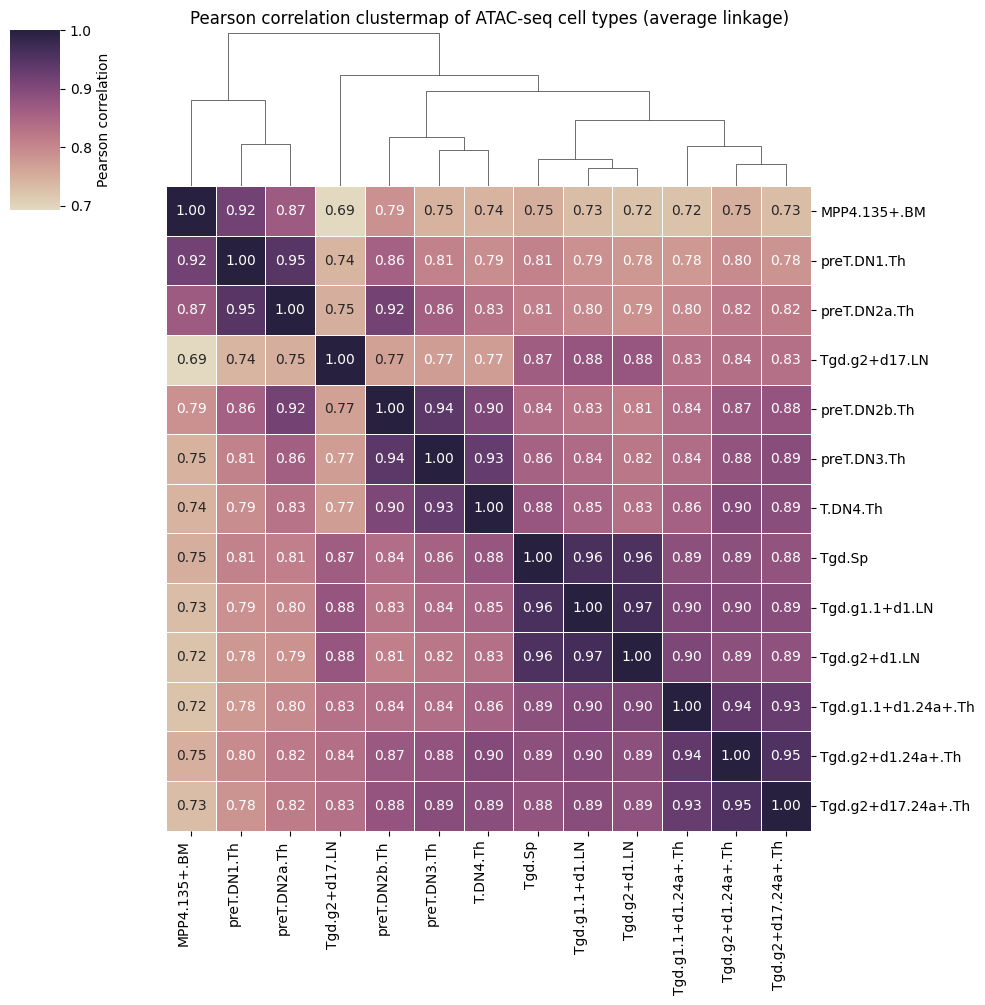

In [2]:
import seaborn as sns

ATAC_gd_corr_matrix_pear = ATAC_seq_gd.corr(method='pearson')

vmin, vmax = ATAC_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_pear,
    cmap=sns.color_palette("ch:s=-.2,r=.6", as_cmap=True),
    center= (ATAC_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of ATAC-seq cell types (average linkage)', y=1)
plt.savefig("tilmann_plots/Pearson correlation clustermap of ATAC-seq cell types (average linkage).png", dpi=300, bbox_inches="tight")
plt.savefig("plots_for_poster/Pearson correlation clustermap of ATAC-seq cell types (average linkage).png", dpi=300, bbox_inches="tight")
plt.show()


- The IL17 expressing Tgd.g2+d17.LN cell type seems to be clustered apart from the other cell types, which should be closer acording to the lineage.
- This is consistent with to results from the PCA analysis
- otherwise the clustering of cell types is very close to the cell lineage
    - early progenitors differ the most from other cell types in their chromatin profile
    - cell types of similar differentiation levels cluster together, rather than cell types, which are directly related
    - likely that differentiation has similar mechanisms in all cell types and is driven by similar changes in chromatin profiles

### heatmap using spearman correlation

In [ ]:
ATAC_gd_corr_matrix_spear = ATAC_seq_gd.corr(method='spearman')

vmin, vmax = ATAC_gd_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of ATAC-seq cell types (average linkage)', y=1)
plt.show()

### trying out different similarity metrics

single linkage

In [ ]:
ATAC_gd_corr_matrix_pear = ATAC_seq_gd.corr(method='pearson')

vmin, vmax = ATAC_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_pear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='single',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of ATAC-seq cell types (single linkage)', y=1)
plt.show()



ATAC_gd_corr_matrix_spear = ATAC_seq_gd.corr(method='spearman')

vmin, vmax = ATAC_gd_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='single',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of ATAC-seq cell types (single linkage)', y=1)
plt.show()

complete linkage

In [ ]:
ATAC_gd_corr_matrix_pear = ATAC_seq_gd.corr(method='pearson')

vmin, vmax = ATAC_gd_corr_matrix_pear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_pear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_pear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='complete',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of ATAC-seq cell types (complete linkage)', y=1)
plt.show()



ATAC_gd_corr_matrix_spear = ATAC_seq_gd.corr(method='spearman')

vmin, vmax = ATAC_gd_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='complete',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of ATAC-seq cell types (complete linkage)', y=1)
plt.show()

- I would choose the clustering with pearson correlation and avarage linkage
    - it shows clustering resembling the cell lineage
    - it uses more information than single and complete linkage
    - it captures the distance IL17 producing Tgd cells have to other cell types better than complete linkage
    - pearson correlation shows the clusters more clearly than spearman with all linkage methods

### seperating TSS OCRs from DE OCRs like in Yoshida et al.

In [ ]:
ATAC_seq_TSSOCRs = ATAC_seq[ATAC_seq["TSS"].notna()].copy()
ATAC_seq_gd_TSSOCRs = ATAC_seq_TSSOCRs[Tgd_cells[1:]].copy()
ATAC_seq_DEOCRs = ATAC_seq[ATAC_seq["TSS"].isna()].copy()
ATAC_seq_gd_DEOCRs = ATAC_seq_DEOCRs[Tgd_cells[1:]].copy()

#### Spearman

In [ ]:
ATAC_gd_DEOCRs_corr_matrix_spear = ATAC_seq_gd_DEOCRs.corr(method='spearman')

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_DEOCRs_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of DEOCRs ATAC-seq cell types', y=1)
plt.show()

ATAC_gd_TSSOCRs_corr_matrix_spear = ATAC_seq_gd_TSSOCRs.corr(method='spearman')

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_spear.min().min(), 1

g = sns.clustermap(
    ATAC_gd_TSSOCRs_corr_matrix_spear,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_spear.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Spearman correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Spearman correlation clustermap of TSSOCRs ATAC-seq cell types', y=1)
plt.show()


- the colormap for both heatmaps is adjusted for the maximum range of both combined (equal to the maximum range of correlation based on DE-OCRs)

#### Pearson

In [ ]:
ATAC_gd_DEOCRs_corr_matrix_pearson = ATAC_seq_gd_DEOCRs.corr(method='pearson')

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_pearson.min().min(), 1

g = sns.clustermap(
    ATAC_gd_DEOCRs_corr_matrix_pearson,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_pearson.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of DEOCRs ATAC-seq cell types', y=1)
plt.savefig("tilmann_plots/Pearson correlation clustermap of DEOCRs ATAC-seq cell types (average linkage).png", dpi=300, bbox_inches="tight")
plt.show()

ATAC_gd_TSSOCRs_corr_matrix_pearson = ATAC_seq_gd_TSSOCRs.corr(method='pearson')

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_pearson.min().min(), 1

g = sns.clustermap(
    ATAC_gd_TSSOCRs_corr_matrix_pearson,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_pearson.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of TSSOCRs ATAC-seq cell types', y=1)
plt.savefig("tilmann_plots/Pearson correlation clustermap of TSSOCRs ATAC-seq cell types (average linkage).png", dpi=300, bbox_inches="tight")
plt.show()

- both spearman and pearson correlation show less variability with the TSS-OCRs

### correcting for the different sizes of the datasets

In [ ]:
# function for corretion created with Claude Sonnet 4.6

from scipy.stats import pearsonr

def weighted_pearson_matrix(df):
    cols = df.columns
    n_cols = len(cols)
    rho_matrix = np.ones((n_cols, n_cols))
    
    for i, col_i in enumerate(cols):
        for j, col_j in enumerate(cols):
            if i >= j:
                continue
            valid = df[[col_i, col_j]].dropna()
            n = len(valid)
            
            if n < 4:
                rho_matrix[i, j] = np.nan
                rho_matrix[j, i] = np.nan
                continue
            
            r, _ = pearsonr(valid[col_i], valid[col_j])
            rho_matrix[i, j] = r
            rho_matrix[j, i] = r
    
    return pd.DataFrame(rho_matrix, index=cols, columns=cols)

In [ ]:
ATAC_gd_DEOCRs_corr_matrix_pearson_weighted = weighted_pearson_matrix(ATAC_seq_gd_DEOCRs)

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_pearson_weighted.min().min(), 1

g = sns.clustermap(
    ATAC_gd_DEOCRs_corr_matrix_pearson_weighted,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_pearson_weighted.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of DEOCRs ATAC-seq cell types (weighted)', y=1)
plt.show()

ATAC_gd_TSSOCRs_corr_matrix_pearson_weighted = weighted_pearson_matrix(ATAC_seq_gd_TSSOCRs)

vmin, vmax = ATAC_gd_DEOCRs_corr_matrix_pearson_weighted.min().min(), 1

g = sns.clustermap(
    ATAC_gd_TSSOCRs_corr_matrix_pearson_weighted,
    cmap='viridis',
    center= (ATAC_gd_DEOCRs_corr_matrix_pearson_weighted.min().min() + 1) / 2,
    vmin=vmin,
    vmax=vmax,
    method='average',
    metric='euclidean',
    row_cluster=True,
    col_cluster=True,
    figsize=(10, 10),
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}
)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_row_dendrogram.set_visible(False)
g.fig.suptitle('Pearson correlation clustermap of TSSOCRs ATAC-seq cell types (weighted)', y=1)
plt.show()

weighting the correlation acording to the size of the dataset makes no difference to the outcome